Importing the required libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**1.Loading the dataset**

Load the dataset "ecommerce_data.csv" using Pandas and display the first few rows to get an
initial understanding of the data.

In [ ]:
df_ecommerce = pd.read_csv('ecommerce.csv')

In [ ]:
# checking the first 5 rows
df_ecommerce.head()

,Order_ID,Customer_ID,Product,Category,Price,Quantity,Order_Date,Country
0,1.0,47.0,Product D,Kitchen,NaN,64.0,7/1/2021,China
1,NaN,NaN,Product A,Clothing,4477.63,93.0,3/21/2021,Pakistan
2,3.0,31.0,Product E,Automobile,5891.07,99.0,3/29/2022,Brazil
3,4.0,40.0,Product H,Clothing,2765.73,83.0,11/7/2022,China
4,5.0,17.0,Product B,Automobile,4594.39,17.0,12/29/2021,Colombia


In [ ]:
# checking the last 5 rows
df_ecommerce.tail()

,Order_ID,Customer_ID,Product,Category,Price,Quantity,Order_Date,Country
995,996.0,18.0,Product F,Kitchen,4288.75,36.0,3/17/2022,China
996,NaN,9.0,Product B,Electronics,2240.62,67.0,3/19/2020,Colombia
997,998.0,48.0,Product G,Accessories,4649.53,1.0,9/18/2022,NaN
998,NaN,50.0,Product B,Kitchen,9547.98,56.0,12/5/2020,Pakistan
999,1000.0,28.0,Product D,Kitchen,NaN,100.0,8/2/2021,Honduras


In [ ]:
# checking the outfit of the dataset
df_ecommerce.shape

(1000, 8)

In [ ]:
# checking the info of data
df_ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Order_ID     882 non-null    float64
 1   Customer_ID  947 non-null    float64
 2   Product      1000 non-null   object 
 3   Category     1000 non-null   object 
 4   Price        875 non-null    float64
 5   Quantity     962 non-null    float64
 6   Order_Date   1000 non-null   object 
 7   Country      910 non-null    object 
dtypes: float64(4), object(4)
memory usage: 62.6+ KB


In [ ]:
# changing the data type of order_date
df_ecommerce['Order_Date'] = pd.to_datetime(df_ecommerce['Order_Date'])

In [ ]:
# checking for duplicate values
df_ecommerce[df_ecommerce.duplicated()]

,Order_ID,Customer_ID,Product,Category,Price,Quantity,Order_Date,Country


In [ ]:
# checking for null values
df_ecommerce.isna().sum()

Order_ID       118
Customer_ID     53
Product          0
Category         0
Price          125
Quantity        38
Order_Date       0
Country         90
dtype: int64

**2. Data Cleaning:**

Check for missing values, duplicated rows, and inconsistent data. Handle any issues found in
this step.

In [ ]:
# filling the order id column with subsequent values where it is null
df_ecommerce['Order_ID'] = df_ecommerce.index+1
df_ecommerce

,Order_ID,Customer_ID,Product,Category,Price,Quantity,Order_Date,Country
0,1,47.0,Product D,Kitchen,NaN,64.0,2021-07-01,China
1,2,NaN,Product A,Clothing,4477.63,93.0,2021-03-21,Pakistan
2,3,31.0,Product E,Automobile,5891.07,99.0,2022-03-29,Brazil
3,4,40.0,Product H,Clothing,2765.73,83.0,2022-11-07,China
4,5,17.0,Product B,Automobile,4594.39,17.0,2021-12-29,Colombia
...,...,...,...,...,...,...,...,...
995,996,18.0,Product F,Kitchen,4288.75,36.0,2022-03-17,China
996,997,9.0,Product B,Electronics,2240.62,67.0,2020-03-19,Colombia
997,998,48.0,Product G,Accessories,4649.53,1.0,2022-09-18,NaN
998,999,50.0,Product B,Kitchen,9547.98,56.0,2020-12-05,Pakistan


In [ ]:
df_ecommerce['Customer_ID'].value_counts()

30.0    25
19.0    25
9.0     25
45.0    25
27.0    24
31.0    24
50.0    24
49.0    24
8.0     24
22.0    23
15.0    22
43.0    22
36.0    22
10.0    22
20.0    21
7.0     21
26.0    21
1.0     21
18.0    21
11.0    20
14.0    20
42.0    20
28.0    20
39.0    20
40.0    20
47.0    20
48.0    19
12.0    19
35.0    19
46.0    19
34.0    19
17.0    19
32.0    18
25.0    17
23.0    17
16.0    17
13.0    16
24.0    16
41.0    15
21.0    14
33.0    14
37.0    14
5.0     14
44.0    14
4.0     14
6.0     12
38.0    12
3.0     11
2.0     11
29.0    11
Name: Customer_ID, dtype: int64

In [ ]:
# storing the most frequent customer_id in a variable
cust_id = np.array([30.0,19.0,9.0,45.0])

In [ ]:
# filling the customer_id with most frequent value
for i in range(0,len(df_ecommerce)):
  if pd.isna(df_ecommerce.loc[i]['Customer_ID']):
    df_ecommerce.iat[i,1] = np.random.choice(cust_id)

In [ ]:
# converting the column as int first
df_ecommerce['Customer_ID'] = df_ecommerce['Customer_ID'].astype(int)
# converting the column as str beacuse it should be a categorical column
df_ecommerce['Customer_ID'] = df_ecommerce['Customer_ID'].astype(str)

Random Sampling after predicting the distribution in Quantity and Price columns

<Axes: xlabel='Quantity', ylabel='Count'>

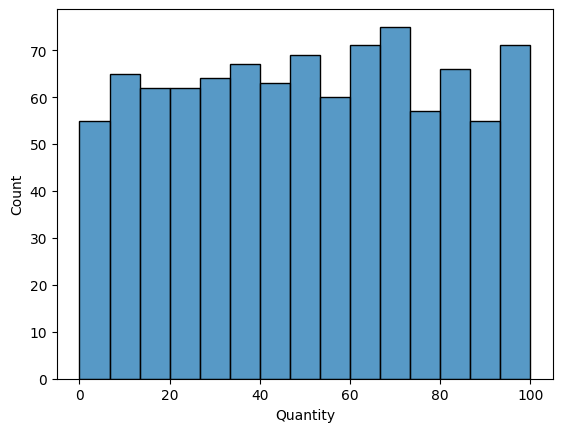

In [ ]:
# plotting the graph to check distribution of quantity column
sns.histplot(x=df_ecommerce['Quantity'],bins=15)

In [ ]:
# assuming mean and std of quantity follow normal distribution
print(np.mean(df_ecommerce['Quantity']))
print(np.std(df_ecommerce['Quantity']))

50.46049896049896
28.591993248486833


In [ ]:
# making a copy of the dataframe
df_ecommerce_cp = df_ecommerce.copy()

In [ ]:
# imputting the uniform value in quantity column where it is null
for i in range(0,len(df_ecommerce_cp)):
  if pd.isna(df_ecommerce_cp.loc[i]['Quantity']):
    df_ecommerce_cp.iat[i,5] = np.random.uniform(0,100)

<Axes: xlabel='Price', ylabel='Count'>

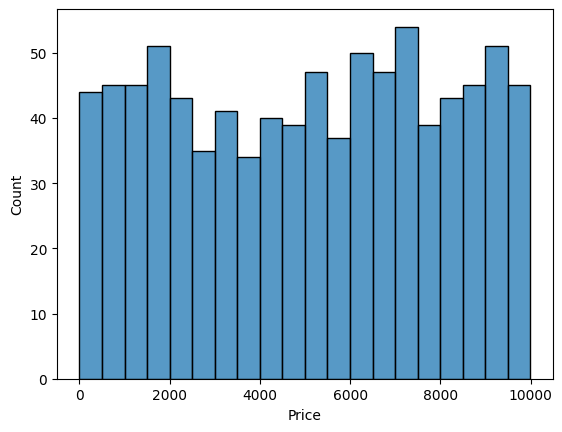

In [ ]:
sns.histplot(x=df_ecommerce['Price'],bins=20)

In [ ]:
# assuming mean and std of quantity follow normal distribution
print(np.mean(df_ecommerce['Price']))
print(np.std(df_ecommerce['Price']))

5074.516811428572
2937.3493142815305


In [ ]:
# imputting the uniform value in quantity column where it is null
for i in range(0,len(df_ecommerce_cp)):
  if pd.isna(df_ecommerce_cp.loc[i]['Price']):
    df_ecommerce_cp.iat[i,4] = np.random.uniform(0,10000)

In [ ]:
# checking the value_counts for country
df_ecommerce_cp['Country'].value_counts()

China          186
Indonesia       95
Russia          55
Philippines     41
Brazil          29
              ... 
Fiji             1
Samoa            1
Uzbekistan       1
Taiwan           1
Israel           1
Name: Country, Length: 120, dtype: int64

In [ ]:
# creating an array of most occuring countries
nation = np.array(['China','Indonesia','Russia'])
nation

array(['China', 'Indonesia', 'Russia'], dtype='<U9')

In [ ]:
# fiiling the null with most occuring countries
for i in range(0,len(df_ecommerce_cp)):
  if pd.isna(df_ecommerce_cp.loc[i]['Country']):
    df_ecommerce_cp.iat[i,7] = np.random.choice(nation)

In [ ]:
# creating the column as mentioned in the problem description
df_ecommerce_cp['Total'] = df_ecommerce_cp['Price']*df_ecommerce_cp['Quantity']

In [ ]:
df_ecommerce_cp.isna().sum()

Order_ID       0
Customer_ID    0
Product        0
Category       0
Price          0
Quantity       0
Order_Date     0
Country        0
Total          0
dtype: int64

**3. Data Summary:**

Calculate and display the following summary statistics:
- Total number of orders.
- Total number of customers.
- Total revenue generated.
- Average order value.

In [ ]:
df_ecommerce_cp['Order_ID'].count()

1000

In [ ]:
df_ecommerce_cp['Customer_ID'].count()

1000

In [ ]:
df_ecommerce_cp['Total'].sum()

255405027.05956882

In [ ]:
df_ecommerce_cp['Total'].mean()

255405.02705956882

**4. Category Analysis:**

Explore the distribution of products across different categories. Provide percentage sales of
each category

In [ ]:
df_cat = df_ecommerce_cp.groupby('Category')['Price'].sum().reset_index().rename(columns={'Price':'cat_total'})
df_cat

,Category,cat_total
0,Accessories,9.319723e+05
1,Automobile,9.081870e+05
2,Clothing,1.186813e+06
3,Electronics,1.035387e+06
4,Kitchen,1.021963e+06


In [ ]:
df_prod = df_ecommerce_cp.groupby(['Category','Product'])['Price'].sum().reset_index().rename(columns={'Price':'prod_total'})
df_prod

,Category,Product,prod_total
0,Accessories,Product A,62626.290000
1,Accessories,Product B,117270.790000
2,Accessories,Product C,123136.133526
3,Accessories,Product D,145230.912258
4,Accessories,Product E,124973.755241
5,Accessories,Product F,110666.903326
6,Accessories,Product G,159967.858782
7,Accessories,Product H,88099.665122
8,Automobile,Product A,88889.189100
9,Automobile,Product B,139307.576844


In [ ]:
df_join_ttl = df_prod.set_index('Category').join(df_cat.set_index('Category'),how='inner').reset_index()
df_join_ttl

,Category,Product,prod_total,cat_total
0,Accessories,Product A,62626.290000,9.319723e+05
1,Accessories,Product B,117270.790000,9.319723e+05
2,Accessories,Product C,123136.133526,9.319723e+05
3,Accessories,Product D,145230.912258,9.319723e+05
4,Accessories,Product E,124973.755241,9.319723e+05
5,Accessories,Product F,110666.903326,9.319723e+05
6,Accessories,Product G,159967.858782,9.319723e+05
7,Accessories,Product H,88099.665122,9.319723e+05
8,Automobile,Product A,88889.189100,9.081870e+05
9,Automobile,Product B,139307.576844,9.081870e+05


In [ ]:
df_join_ttl['Percent share'] = df_join_ttl['prod_total']/df_join_ttl['cat_total']*100
df_join_ttl

,Category,Product,prod_total,cat_total,Percent share
0,Accessories,Product A,62626.290000,9.319723e+05,6.719759
1,Accessories,Product B,117270.790000,9.319723e+05,12.583077
2,Accessories,Product C,123136.133526,9.319723e+05,13.212424
3,Accessories,Product D,145230.912258,9.319723e+05,15.583179
4,Accessories,Product E,124973.755241,9.319723e+05,13.409600
5,Accessories,Product F,110666.903326,9.319723e+05,11.874484
6,Accessories,Product G,159967.858782,9.319723e+05,17.164443
7,Accessories,Product H,88099.665122,9.319723e+05,9.453035
8,Automobile,Product A,88889.189100,9.081870e+05,9.787543
9,Automobile,Product B,139307.576844,9.081870e+05,15.339085


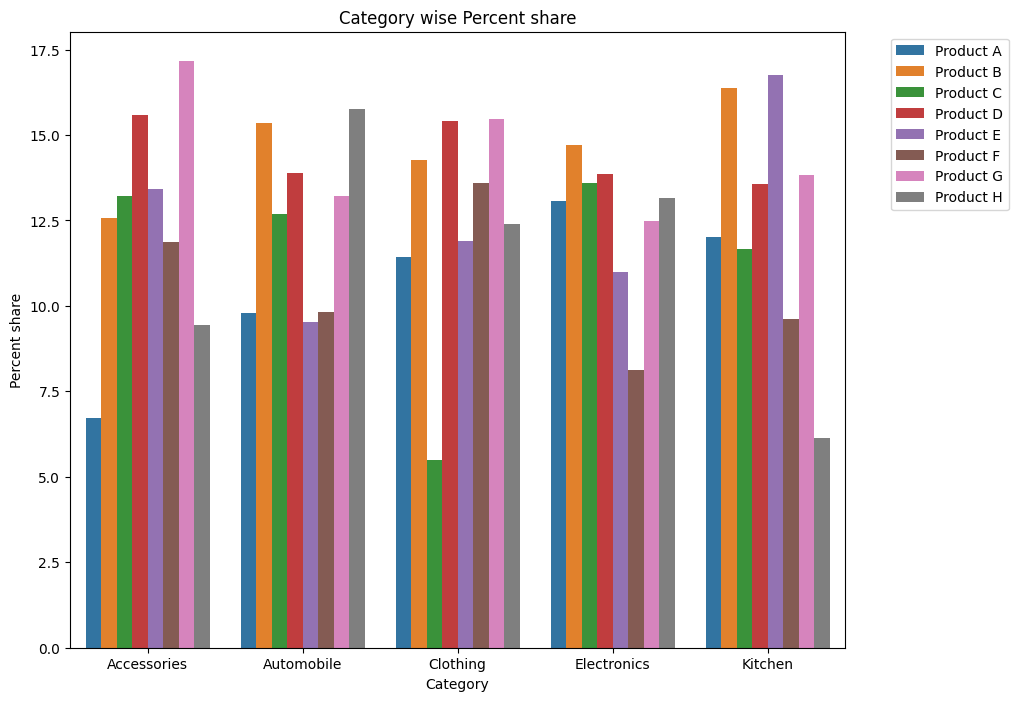

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(x='Category',y='Percent share',hue='Product',data=df_join_ttl)
plt.title('Category wise Percent share')
plt.legend(bbox_to_anchor = (1.05,1),loc='best')
plt.show()

**5. Country-wise Analysis:**

Identify the top 5 countries with the highest number of orders. Create a bar plot to visualize this
information.

In [ ]:
df_hgst_ordr = df_ecommerce_cp.groupby('Country')['Order_ID'].count().sort_values(ascending=False).reset_index().rename(columns={'Order_ID':'Order_count'})[:5]
df_hgst_ordr

,Country,Order_count
0,China,225
1,Indonesia,117
2,Russia,84
3,Philippines,41
4,Brazil,29


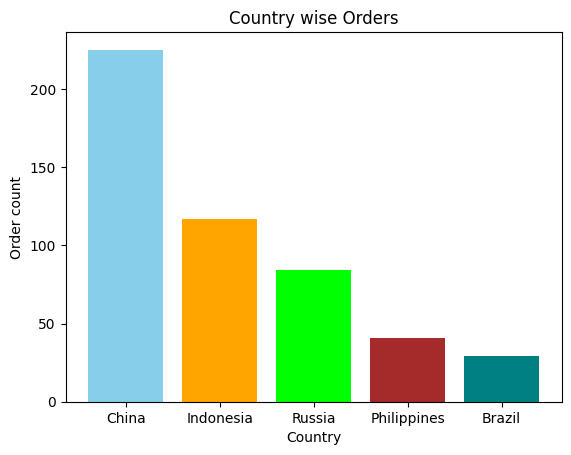

In [ ]:
plt.bar(df_hgst_ordr['Country'],df_hgst_ordr['Order_count'],color=['skyblue','orange','lime','brown','teal'])
plt.xlabel('Country')
plt.ylabel('Order count')
plt.title('Country wise Orders')
plt.show()

**6. Monthly Analysis:**

Show the monthly revenue over the entire dataset's time period.

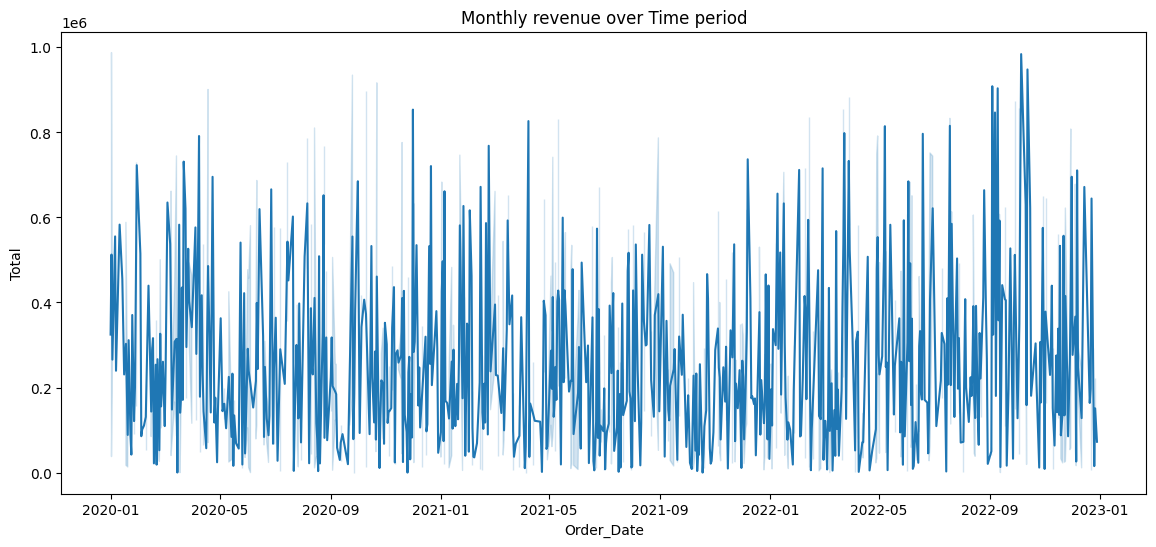

In [ ]:
plt.figure(figsize=(14,6))
sns.lineplot(x='Order_Date',y='Total',data=df_ecommerce_cp)
plt.title('Monthly revenue over Time period')
plt.show()

**7. Customer Insights:**

Identify the top 5 customers who have spent the most. Display their names and total spending.

In [ ]:
df_ttl_spnd = df_ecommerce_cp.groupby('Customer_ID')['Total'].sum().sort_values(ascending=False).reset_index()[:5]
df_ttl_spnd

,Customer_ID,Total
0,30,1.212864e+07
1,45,1.155650e+07
2,9,1.046620e+07
3,19,9.366802e+06
4,10,7.573112e+06


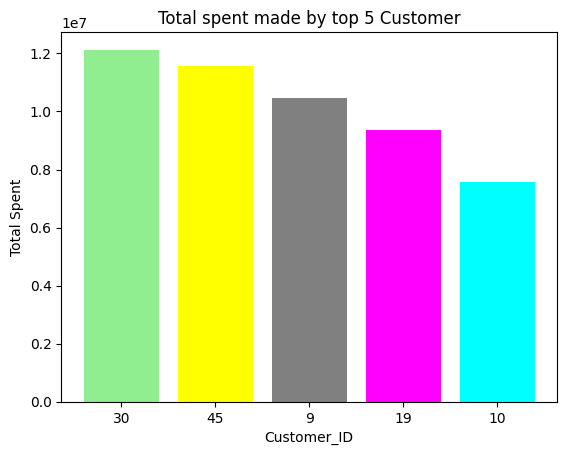

In [ ]:
plt.bar(df_ttl_spnd['Customer_ID'],df_ttl_spnd['Total'],color=['lightgreen','yellow','grey','magenta','aqua'])
plt.xlabel('Customer_ID')
plt.ylabel('Total Spent')
plt.title('Total spent made by top 5 Customer')
plt.show()

**8. Price Distribution:**

Show the distribution of product prices between different ranges.

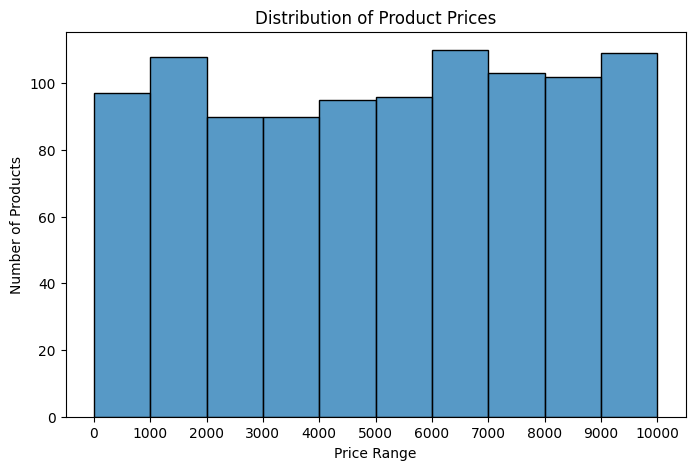

In [ ]:
plt.figure(figsize=(8,5))
price_ranges = [0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
sns.histplot(df_ecommerce_cp['Price'],bins=price_ranges)
plt.xlabel('Price Range')
plt.ylabel('Number of Products')
plt.title('Distribution of Product Prices')
plt.xticks(price_ranges)
plt.show()

**10. Time-based Analysis:**

Explore how sales have evolved over time. Average sales yearly, and quaterly

In [ ]:
# extracting the year and quarter part from Order_Date column
df_ecommerce_cp['Year'] = df_ecommerce_cp['Order_Date'].dt.year
df_ecommerce_cp['Quarter'] = df_ecommerce_cp['Order_Date'].dt.quarter

In [ ]:
# calculating average sales yearly
avg_yrly_sales = df_ecommerce_cp.groupby('Year')['Total'].mean()
avg_yrly_sales

Year
2020    256069.549377
2021    228745.027660
2022    282140.772825
Name: Total, dtype: float64

In [ ]:
# calculating average sales quarterly
avg_qrtrly_sales = df_ecommerce_cp.groupby('Quarter')['Total'].mean()
avg_qrtrly_sales

Quarter
1    264046.824970
2    246029.914616
3    267337.435720
4    246391.401322
Name: Total, dtype: float64

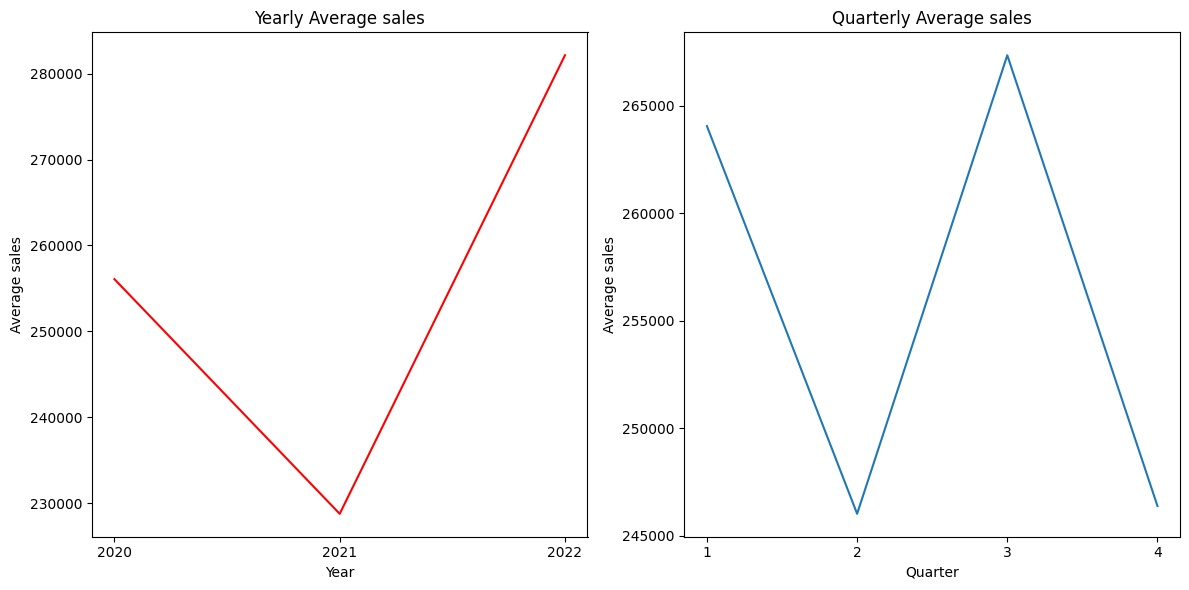

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

sns.lineplot(x=avg_yrly_sales.index,y=avg_yrly_sales.values,color='red',ax=ax1)
ax1.set_xticks(avg_yrly_sales.index)
ax1.set_ylabel('Average sales')
ax1.set_title('Yearly Average sales')

sns.lineplot(x=avg_qrtrly_sales.index,y=avg_qrtrly_sales.values,ax=ax2)
ax2.set_xticks(avg_qrtrly_sales.index)
ax2.set_ylabel('Average sales')
ax2.set_title('Quarterly Average sales')

plt.tight_layout()
plt.show()